In [1]:
import os
import pandas as pd
import numpy as np
import json
import pickle
from scipy import stats
from statsmodels.stats.multitest import multipletests
from tqdm import tqdm
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.pylab as pylab
from matplotlib import font_manager
from matplotlib.colors import LinearSegmentedColormap
from cmap import Colormap
from matplotlib.patches import Rectangle
from statannotations.Annotator import Annotator

font_path = "fonts/Arial.ttf"  # Example path, adjust as necessary
font_manager.fontManager.addfont(font_path)
font_path = "fonts/Arial_Bold.ttf"  # Example path, adjust as necessary
font_manager.fontManager.addfont(font_path)
pastel_palette = sns.color_palette("pastel")
pastel_colors_hex = pastel_palette.as_hex()
colors = [pastel_colors_hex[0], "#FFFFFF", pastel_colors_hex[1]]
cmap_name = 'pastel_blue_white_pastel_orange'
cm1 = LinearSegmentedColormap.from_list(cmap_name, colors)
colors = [pastel_colors_hex[1], "#FFFFFF", pastel_colors_hex[0]]
cmap_name = 'pastel_blue_white_pastel_orange'
cm2 = LinearSegmentedColormap.from_list(cmap_name, colors)
cm_cividis = plt.cm.cividis.copy()
cm_cividis_r = plt.cm.cividis_r.copy()
cm_batlow = Colormap('crameri:batlow').to_mpl()
batlow10 = cm_batlow(np.linspace(0,1,10)).tolist()
cividis10 = cm_cividis(np.linspace(0,1,10)).tolist()

def get_rank_id(values, return_nan=False, ascending=False, test='wilcoxon'):
    """Iterative rank assignment within one dataset.

    Revision (r2): comparisons are TWO-SIDED and all pairwise p-values contributing to a
    given dataset's ranking are adjusted together with the Benjamini-Hochberg FDR
    procedure. Models share a rank when not distinguishable at adjusted P > 0.05.
    (Previously: one-sided `alternative='less'`, uncorrected -- the direction was chosen
    from the observed means, which halved p-values systematically.)
    """
    valid_index = []
    if ascending:
        for i in range(len(values)):
            values[i] = - values[i]
    for i, v in enumerate(values):
        if v.__class__ == np.ndarray:
            valid_index.append(i)
    n = len(valid_index)
    rank_id = [0] * n
    v_mean = [values[i].mean() for i in valid_index]

    # --- pre-compute the full within-dataset family of pairwise tests, then BH-adjust ---
    raw_p, pair_keys = [], []
    for a in range(n):
        for b in range(a + 1, n):
            va, vb = values[valid_index[a]], values[valid_index[b]]
            if np.array_equal(va, vb):
                p = 1.0
            elif test == 'wilcoxon':
                p = stats.wilcoxon(va, vb, alternative='two-sided').pvalue
            elif test == 'paired t-test':
                p = stats.ttest_rel(va, vb, alternative='two-sided').pvalue
            raw_p.append(p)
            pair_keys.append((a, b))
    if raw_p:
        adj_p = multipletests(raw_p, method='fdr_bh')[1]
    else:
        adj_p = []
    P = {}
    for (a, b), p in zip(pair_keys, adj_p):
        P[(a, b)] = p
        P[(b, a)] = p

    while 0 in rank_id:
        current_rank_id = n - rank_id.count(0) + 1
        n_best = np.argmax(v_mean)
        assert rank_id[n_best] == 0
        rank_id[n_best] = current_rank_id
        v_mean[n_best] = - 100.
        for i in range(n):
            if i != n_best and rank_id[i] == 0:
                if P[(i, n_best)] > 0.05:
                    rank_id[i] = current_rank_id
                    v_mean[i] = - 100.
    if return_nan:
        return [rank_id[valid_index.index(i)] if i in valid_index else values[i] for i in range(len(values))]
    else:
        return rank_id

def get_normalized_data(matrix, mask):
    if mask is None:
        mask = np.zeros_like(matrix, dtype=bool)
    normalized_data = np.zeros_like(matrix)
    for i in range(matrix.shape[0]):
        row = matrix[i, :]
        # Skip normalization if the row is masked completely
        if not mask[i, :].all():
            row_min, row_max = np.min(row[~mask[i, :]]), np.max(row[~mask[i, :]])
            # Check if min and max are different to avoid division by zero
            if row_min != row_max:
                normalized_data[i, :] = (row - row_min) / (row_max - row_min)
            else:
                normalized_data[i, :] = 0.5  # Use a middle value if min=max
    return normalized_data

def get_tsne(smiles_list):
    """
    Generate 2D t-SNE embeddings from a list of SMILES strings.
    
    Parameters:
    -----------
    smiles_list : list
        List of SMILES strings representing molecules
    
    Returns:
    --------
    numpy.ndarray
        2D t-SNE embedding coordinates with shape (n_molecules, 2)
    """
    from rdkit import Chem
    from rdkit.Chem import rdMolDescriptors
    from rdkit.Chem.rdFingerprintGenerator import GetMorganGenerator
    import numpy as np
    from sklearn.manifold import TSNE
    
    # Convert SMILES to Morgan fingerprints using the new MorganGenerator
    fingerprints = []
    valid_smiles = []
    
    # Create a Morgan fingerprint generator with radius 2 and 2048 bits
    morgan_gen = GetMorganGenerator(radius=2, fpSize=2048)
    
    for smiles in smiles_list:
        mol = Chem.MolFromSmiles(smiles)
        if mol is not None:
            # Generate Morgan fingerprint with the generator
            fp = morgan_gen.GetFingerprint(mol)
            fingerprints.append(fp.ToList())
            valid_smiles.append(smiles)
        else:
            print(f"Warning: Could not parse SMILES: {smiles}")
    
    # Convert list of fingerprints to a numpy array
    X = np.array(fingerprints)
    
    # Check if we have valid molecules
    if len(X) == 0:
        raise ValueError("No valid molecules found in the input SMILES list")
    
    # Apply t-SNE
    tsne = TSNE(n_components=2, random_state=42)
    tsne_results = tsne.fit_transform(X)
    
    return tsne_results

In [2]:
model2name1 = {
    "AtomPair": "RF-AtomPair",
    "Avalon": "RF-Avalon",
    "AvalonCount": "RF-AvalonCount",
    "Layered": "RF-Layered",
    "MACCSKEY": "RF-MACCSKEY",
    "Morgan": "RF-Morgan",
    "MorganCount": "RF-MorganCount",
    "Pattern": "RF-Pattern",
    "RDKitNorm": "RF-RDKit",
    "RDKitTopol": "RF-RDKitTopol",
    "Torsion": "RF-Torsion",
    "DMPNN_BinaryClassification_Config": "DMPNN",
    "DMPNN_BinaryClassificationDropout_Config": "DMPNN(Dropout)",
    "DMPNN_BinaryClassificationEnsemble_Config": "DMPNN(Ensemble)",
    'DMPNN_Regression_Config': "DMPNN",
    "DMPNN_RegressionDropout_Config": "DMPNN(Dropout)",
    "DMPNN_RegressionEnsemble_Config": "DMPNN(Ensemble)",
    "DMPNN_RegressionEvidential_Config": "DMPNN(Evidential)",
    "DMPNN_RegressionEvidentialAleatoric_Config": "DMPNN(Evidential Aleatoric)",
    "DMPNN_RegressionEvidentialEpistemic_Config": "DMPNN(Evidential Epistemic)",
    "DMPNN_RegressionMVE_Config": "DMPNN(MVE)",
    "GRU_SELFIES_Config": "GRU",
    "LSTM_SELFIES_Config": "LSTM",
    "GaussianProcessRegressionDecisionBoundaryUncertainty_MarginalizedGraphKernel_Config": "GPR-MGK",
    "GaussianProcessRegressionPosteriorUncertainty_MarginalizedGraphKernel_Config": "GPR-MGK",
    "passive": "Random Control",
    "DMPNN+RDKitNorm_BinaryClassification_Config": "DMPNN-RDKit",
    "DMPNN+MorganCount_BinaryClassification_Config": "DMPNN-MorganCount",
    "GaussianProcessRegressionDecisionBoundaryUncertainty_MarginalizedGraphKernel+RBFKernelRDKitNorm_Config": "GPR-MGK-RDKit",
    'GaussianProcessRegressionPosteriorUncertainty_MarginalizedGraphKernel+RBFKernelRDKitNorm_Config': "GPR-MGK-RDKit",
    "DMPNN+MorganCount_RegressionDropout_Config": "DMPNN-MorganCount(Dropout)",
    "DMPNN+RDKitNorm_RegressionDropout_Config": "DMPNN-RDKit(Dropout)",
    'DMPNN+RDKitNorm_Regression_Config': 'DMPNN-RDKit',
    "GraphGPS_BinaryClassification_Config": "GraphGPS",
    'GraphGPS_Regression_Config': 'GraphGPS',
    'MolFormer_Config': 'MolFormer'
}
model2name2 = model2name1.copy()
model2name2.update({
    "GaussianProcessRegressionDecisionBoundaryUncertainty_MarginalizedGraphKernel_Config": r'GPR$_{\rm dbu}$-MGK',
    "GaussianProcessRegressionPosteriorUncertainty_MarginalizedGraphKernel_Config": r'GPR$_{\rm pu}$-MGK',
    "GaussianProcessRegressionDecisionBoundaryUncertainty_MarginalizedGraphKernel+RBFKernelRDKitNorm_Config": r'GPR$_{\rm dbu}$-MGK-RDKit',
    "GaussianProcessRegressionPosteriorUncertainty_MarginalizedGraphKernel+RBFKernelRDKitNorm_Config": r'GPR$_{\rm pu}$-MGK-RDKit',
})

In [3]:
df1 = pd.read_csv('../data/processed/results_summary_classification_exploitive.csv')
df1["model"] = df1["model"].apply(lambda x: model2name1[x])
df1["performance"] = df1["traj"].apply(lambda x: json.loads(x)[-1])
datasets1 = ['CHEMBL217-1', 'CHEMBL219-1', 'CHEMBL259-1', 'ALDH1', 'PKM2', 'VDR', ]
models1 = ['RF-AtomPair', 'RF-Avalon', 'RF-AvalonCount', 'RF-Layered', 
           'RF-MACCSKEY', 'RF-Morgan', 'RF-MorganCount', 'RF-Pattern', 
           'RF-RDKit', 'RF-RDKitTopol', 'RF-Torsion', 
           'GPR-MGK', 'GPR-MGK-RDKit', 'DMPNN', 'DMPNN-MorganCount', 'GraphGPS', 'MolFormer']

rank_matrix = []
perf_matrix = []
for i, dataset in enumerate(datasets1):
    values_al = []
    perf_al = []
    for j, model in enumerate(models1):
        df = df1[(df1.dataset == dataset) & (df1.model == model)]
        if len(df) == 0:
            values_al.append(np.nan)
            perf_al.append(np.nan)
        else:
            assert len(df) == 40
            values_al.append(df['performance'].to_numpy())
            perf_al.append(df['performance'].to_numpy().mean())
    rank_matrix.append(get_rank_id(values_al, return_nan=True))
    perf_matrix.append(perf_al)
rank_matrix1 = np.array(rank_matrix)
perf_matrix1 = np.array(perf_matrix)
mask1 = np.isnan(rank_matrix1)

df_alef14 = pd.DataFrame({'dataset': [], 'model': [], 'task': [], 'batch_size': [], 'Batch size level': [], 'tag': [], 'ALEF': []})
df_bs = pd.DataFrame({'dataset': [], 'model': [], 'task': [], 'batch_size1': [], 'batch_size2': [], 'Batch size ratio': [], 'value': []})
# Get active learning effectiveness rate
al_effectiveness1 = [np.zeros((len(datasets1), len(models1))) for _ in range(4)]
for i, dataset in enumerate(datasets1):
    for j, model in enumerate(models1):
        df = df1[(df1.model == model) & (df1.dataset == dataset)]
        if len(df) == 0:
            continue
        else:
            assert len(df) == 40
            unique_batch_sizes = df.batch_size.unique()
            assert list(unique_batch_sizes) == sorted(unique_batch_sizes), "Batch sizes are not in ascending order"
            for k, bs in enumerate(unique_batch_sizes):
                active = df[(df.batch_size == bs)]['performance'].to_numpy()
                alef = (active > 1).sum() / len(active)
                al_effectiveness1[k][i][j] = alef
                df_alef14.loc[len(df_alef14)] = dataset, model, 'Exploitation & Classification', bs, k+1, 'All models', alef
                if rank_matrix1[i][j] <= 5:
                    df_alef14.loc[len(df_alef14)] = dataset, model, 'Exploitation & Classification', bs, k+1, r'Model rank $\leq$ 5', alef
                # if rank_matrix1[i][j] == 1:
                #     df_alef14.loc[len(df_alef14)] = dataset, model, 'Exploitation & Classification', bs, k+1, 'Model rank = 1', alef
                    for l in range(k + 1, 4):
                        bs_ = unique_batch_sizes[l]
                        assert bs < bs_
                        active_ = df[(df.batch_size == bs_)]['performance'].to_numpy()
                        value = (active > active_).sum() / len(active)
                        df_bs.loc[len(df_bs)] = dataset, model, 'Exploitation & Classification', bs, bs_, 'x%d' % int(bs_ / bs), value

In [4]:
df2 = pd.read_csv('../data/processed/results_summary_classification_explorative.csv')

def sample_to_length(original_list, target_length):
    if len(original_list) <= target_length:
        return original_list  # Return original if it's already shorter than or equal to target
    
    # Calculate indices using numpy's linspace to get evenly spaced points
    indices = np.linspace(0, len(original_list) - 1, target_length, dtype=int)
    
    # Sample the list at those indices
    sampled_list = [original_list[i] for i in indices]
    
    return sampled_list

df2["model"] = df2["model"].apply(lambda x: model2name2[x])
df2 = df2[df2.metric == "mcc"].reset_index(drop=True)
df2["traj"].apply(lambda x: sample_to_length(json.loads(x), 11))
df2["performance"] = df2["traj"].apply(lambda x: np.mean(json.loads(x)))
df2['batch_size'] = df2.apply(lambda x: x['batch_size'] if x['learning_type'] == 'active' else 'passive', axis=1)
df2['dataset'] = df2.apply(lambda x: '%s (%s)' % (x['dataset'], x['split_type']), axis=1)

datasets2 = ['CHEMBL217-1 (random)', 'CHEMBL217-1 (scaffold)', 'CHEMBL217-1 (SIMPD)', 
             'CHEMBL219-1 (random)', 'CHEMBL219-1 (scaffold)', 'CHEMBL219-1 (SIMPD)', 
             'ames (random)', 'ames (scaffold)', 
             'CYP3A4_Veith (random)', 'CYP3A4_Veith (scaffold)']
models2 = ['RF-AtomPair', 'RF-Avalon', 'RF-AvalonCount', 'RF-Layered', 
           'RF-MACCSKEY', 'RF-Morgan', 'RF-MorganCount', 'RF-Pattern', 
           'RF-RDKit', 'RF-RDKitTopol', 'RF-Torsion', r'GPR$_{\rm pu}$-MGK', r'GPR$_{\rm dbu}$-MGK', r'GPR$_{\rm dbu}$-MGK-RDKit',
           'DMPNN', 'DMPNN-MorganCount', 'DMPNN-RDKit', 'DMPNN(Dropout)', 'DMPNN(Ensemble)', 'GraphGPS',
           'MolFormer']
# Get model rank
df2_ = df2[df2.learning_type == 'active'].reset_index(drop=True)
rank_matrix = []
perf_matrix = []
for i, dataset in enumerate(datasets2):
    values_al = []
    perf_al = []
    for j, model in enumerate(models2):
        df = df2_[(df2_.dataset == dataset) & (df2_.model == model)]
        if len(df) == 0:
            values_al.append(np.nan)
            perf_al.append(np.nan)
        else:
            assert len(df) == 40
            values_al.append(df['performance'].to_numpy())
            perf_al.append(df['performance'].to_numpy().mean())
    rank_matrix.append(get_rank_id(values_al, return_nan=True))
    perf_matrix.append(perf_al)
rank_matrix2 = np.array(rank_matrix)
perf_matrix2 = np.array(perf_matrix)
mask2 = np.isnan(rank_matrix2)

# Get active learning effectiveness rate
al_effectiveness2 = [np.zeros((len(datasets2), len(models2))) for _ in range(4)]
for i, dataset in enumerate(datasets2):
    for j, model in enumerate(models2):
        df = df2[(df2.model == model) & (df2.dataset == dataset)]
        if len(df) == 0:
            continue
        else:
            assert len(df) == 50
            passive = df[df.learning_type == 'passive']['performance'].to_numpy()
            unique_batch_sizes = df.batch_size.unique()[:4]
            assert list(unique_batch_sizes) == sorted(unique_batch_sizes), "Batch sizes are not in ascending order"
            for k, bs in enumerate(unique_batch_sizes):
                active = df[(df.learning_type == 'active')&(df.batch_size == bs)]['performance'].to_numpy()
                alef = (active > passive).sum() / len(active)
                al_effectiveness2[k][i][j] = alef
                df_alef14.loc[len(df_alef14)] = dataset, model, 'Exploration & Classification', bs, k+1, 'All models', alef
                # if rank_matrix2[i][j] == 1:
                #     df_alef14.loc[len(df_alef14)] = dataset, model, 'Exploration & Classification', bs, k+1, 'Model rank = 1', alef
                if rank_matrix2[i][j] <= 5:
                    df_alef14.loc[len(df_alef14)] = dataset, model, 'Exploration & Classification', bs, k+1, r'Model rank $\leq$ 5', alef
                    
                    for l in range(k + 1, 4):
                        bs_ = unique_batch_sizes[l]
                        assert bs < bs_
                        active_ = df[(df.batch_size == bs_)]['performance'].to_numpy()
                        value = (active > active_).sum() / len(active)
                        df_bs.loc[len(df_bs)] = dataset, model, 'Exploration & Classification', bs, bs_, 'x%d' % int(bs_ / bs), value

In [5]:
df3 = pd.read_csv('../data/processed/results_summary_regression_exploitive.csv')
df3["model"] = df3["model"].apply(lambda x: model2name1[x])
df3["performance"] = df3["traj"].apply(lambda x: json.loads(x)[-1])
datasets3 = ['CHEMBL217-1', 'CHEMBL219-1', 'CHEMBL259-1', 'Enamine10k_scores', 'Enamine50k_scores', 'EnamineHTS_scores']
models3 = ['RF-AtomPair', 'RF-Avalon', 'RF-AvalonCount', 'RF-Layered', 
           'RF-MACCSKEY', 'RF-Morgan', 'RF-MorganCount', 'RF-Pattern', 
           'RF-RDKit', 'RF-RDKitTopol', 'RF-Torsion', 'GPR-MGK', 'GPR-MGK-RDKit', 
           'DMPNN', 'DMPNN-RDKit', 'GraphGPS', 'MolFormer']

rank_matrix = []
perf_matrix = []
for i, dataset in enumerate(datasets3):
    values_al = []
    perf_al = []
    for j, model in enumerate(models3):
        df = df3[(df3.dataset == dataset) & (df3.model == model)]
        if len(df) == 0:
            values_al.append(np.nan)
            perf_al.append(np.nan)
        else:
            assert len(df) == 40
            values_al.append(df['performance'].to_numpy())
            perf_al.append(df['performance'].to_numpy().mean())
    rank_matrix.append(get_rank_id(values_al, return_nan=True))
    perf_matrix.append(perf_al)
rank_matrix3 = np.array(rank_matrix)
perf_matrix3 = np.array(perf_matrix)
mask3 = np.isnan(rank_matrix3)

# Get active learning effectiveness rate
al_effectiveness3 = [np.zeros((len(datasets3), len(models3))) for _ in range(4)]
for i, dataset in enumerate(datasets3):
    for j, model in enumerate(models3):
        df = df3[(df3.model == model) & (df3.dataset == dataset)]
        if len(df) == 0:
            continue
        else:
            assert len(df) == 40
            unique_batch_sizes = df.batch_size.unique()
            assert list(unique_batch_sizes) == sorted(unique_batch_sizes), "Batch sizes are not in ascending order"
            for k, bs in enumerate(unique_batch_sizes):
                active = df[(df.batch_size == bs)]['performance'].to_numpy()
                alef = (active > 1).sum() / len(active)
                al_effectiveness3[k][i][j] = alef
                df_alef14.loc[len(df_alef14)] = dataset, model, 'Exploitation & Regression', bs, k+1, 'All models', alef
                # if rank_matrix3[i][j] == 1:
                #     df_alef14.loc[len(df_alef14)] = dataset, model, 'Exploitation & Regression', bs, k+1, 'Model rank = 1', alef
                if rank_matrix3[i][j] <= 5:
                    df_alef14.loc[len(df_alef14)] = dataset, model, 'Exploitation & Regression', bs, k+1, r'Model rank $\leq$ 5', alef
                    
                    for l in range(k + 1, 4):
                        bs_ = unique_batch_sizes[l]
                        assert bs < bs_
                        active_ = df[(df.batch_size == bs_)]['performance'].to_numpy()
                        value = (active > active_).sum() / len(active)
                        df_bs.loc[len(df_bs)] = dataset, model, 'Exploitation & Regression', bs, bs_, 'x%d' % int(bs_ / bs), value

In [6]:
df4 = pd.read_csv('../data/processed/results_summary_regression_explorative.csv')

def sample_to_length(original_list, target_length):
    if len(original_list) <= target_length:
        return original_list  # Return original if it's already shorter than or equal to target
    
    # Calculate indices using numpy's linspace to get evenly spaced points
    indices = np.linspace(0, len(original_list) - 1, target_length, dtype=int)
    
    # Sample the list at those indices
    sampled_list = [original_list[i] for i in indices]
    
    return sampled_list

df4["model"] = df4["model"].apply(lambda x: model2name2[x])
df4 = df4[df4.metric == "rmse"].reset_index(drop=True)
df4["traj"].apply(lambda x: sample_to_length(json.loads(x), 11))
df4["performance"] = df4["traj"].apply(lambda x: np.mean(json.loads(x)))
df4['batch_size'] = df4.apply(lambda x: x['batch_size'] if x['learning_type'] == 'active' else 'passive', axis=1)
df4['dataset'] = df4.apply(lambda x: '%s (%s)' % (x['dataset'], x['split_type']), axis=1)

datasets4 = ['CHEMBL217-1 (random)', 'CHEMBL217-1 (scaffold)', 'CHEMBL217-1 (SIMPD)', 
             'CHEMBL219-1 (random)', 'CHEMBL219-1 (scaffold)', 'CHEMBL219-1 (SIMPD)', 
             'aqueous_solubility (random)', 'aqueous_solubility (scaffold)', 
             'human_liver_microsome_stability (random)', 'human_liver_microsome_stability (scaffold)']
models4 = ['RF-AtomPair', 'RF-Avalon', 'RF-AvalonCount', 'RF-Layered', 
           'RF-MACCSKEY', 'RF-Morgan', 'RF-MorganCount', 'RF-Pattern', 
           'RF-RDKit', 'RF-RDKitTopol', 'RF-Torsion', r'GPR$_{\rm pu}$-MGK', r'GPR$_{\rm pu}$-MGK-RDKit',
           'DMPNN(Dropout)', 'DMPNN-MorganCount(Dropout)', 'DMPNN-RDKit(Dropout)', 'DMPNN(Ensemble)', 'DMPNN(MVE)',
           'DMPNN(Evidential)', 'DMPNN(Evidential Aleatoric)', 'DMPNN(Evidential Epistemic)']
df4_ = df4[df4.learning_type == 'active'].reset_index(drop=True)
# Get model rank
rank_matrix = []
perf_matrix = []
for i, dataset in enumerate(datasets4):
    values_al = []
    perf_al = []
    for j, model in enumerate(models4):
        df = df4_[(df4_.dataset == dataset) & (df4_.model == model)]
        assert len(df) == 40
        values_al.append(df['performance'].tolist())
        perf_al.append(df['performance'].mean())
    values_al = np.array(values_al)
    rank_matrix.append(get_rank_id(values_al, ascending=True))
    perf_matrix.append(perf_al)
rank_matrix4 = np.array(rank_matrix)
perf_matrix4 = np.array(perf_matrix)
mask4 = np.isnan(rank_matrix4)

# Get al effectiveness
al_effectiveness4 = [np.zeros((len(datasets4), len(models4))) for _ in range(4)]
for i, dataset in enumerate(datasets4):
    for j, model in enumerate(models4):
        df = df4[(df4.model == model) & (df4.dataset == dataset)]
        assert len(df) == 50
        passive = df[df.learning_type == 'passive']['performance'].to_numpy()
        unique_batch_sizes = df.batch_size.unique()[:4]
        assert list(unique_batch_sizes) == sorted(unique_batch_sizes), "Batch sizes are not in ascending order"
        for k, bs in enumerate(unique_batch_sizes):
            if bs == 'passive':
                continue
            active = df[(df.learning_type == 'active')&(df.batch_size == bs)]['performance'].to_numpy()
            
            # if every element in active - passive is all zero
            if np.all(np.array(active) - np.array(passive) == 0.):
                pass
            else:
                alef = (active < passive).sum() / len(active)
                al_effectiveness4[k][i][j] = alef
                df_alef14.loc[len(df_alef14)] = dataset, model, 'Exploration & Regression', bs, k+1, 'All models', alef
                # if rank_matrix4[i][j] == 1:
                #     df_alef14.loc[len(df_alef14)] = dataset, model, 'Exploration & Regression', bs, k+1, 'Model rank = 1', alef
                if rank_matrix4[i][j] <= 5:
                    df_alef14.loc[len(df_alef14)] = dataset, model, 'Exploration & Regression', bs, k+1, r'Model rank $\leq$ 5', alef
                    
                    for l in range(k + 1, 4):
                        bs_ = unique_batch_sizes[l]
                        assert bs < bs_
                        active_ = df[(df.batch_size == bs_)]['performance'].to_numpy()
                        value = (active < active_).sum() / len(active)
                        df_bs.loc[len(df_bs)] = dataset, model, 'Exploration & Regression', bs, bs_, 'x%d' % int(bs_ / bs), value
df_alef14['ALEF'] *= 100
df_bs['value'] *= 100

In [7]:
def format_model_names(models):
    return [m.replace('RBF-RDKit', 'RDKit').replace('DPK-Morgan', 'Morgan').
            replace('GPRv', r'GPR$\rm _{dbu}$').replace('GPRu', r'GPR$\rm _{pu}$') for m in models]

datasets_s = ['carcinogens_lagunin', 'skin', 'dili', 'hia_hou', 
              'bioavailability_ma', 'herg']
datasets_l = ['pgp_broccatelli', 'ames', 'CYP2C19_Veith']
datasets = datasets_s + datasets_l
datasets_name = ['Carcinogens', 'Skin', 'DILI', 'HIA', 'Bioavailability', 'hERG', 
                 'Pgp', 'Ames', 'CYP2C19']
models_cv = ['RF-Morgan', 'RF-RDKit', 
          'GPR-DPK-Morgan', 'GPC-DPK-Morgan', 'SVC-DPK-Morgan', 
          'GPR-RBF-RDKit', 'GPC-RBF-RDKit', 'SVC-RBF-RDKit', 
          'GPR-MGK', 'GPC-MGK', 'SVC-MGK', 
          'GPR-MGK-DPK-Morgan', 'GPC-MGK-DPK-Morgan', 'SVC-MGK-DPK-Morgan', 
          'GPR-MGK-RBF-RDKit', 'GPC-MGK-RBF-RDKit', 'SVC-MGK-RBF-RDKit', 
          'MLP-Morgan', 'MLP-RDKit', 'D-MPNN', 'D-MPNN-Morgan', 'D-MPNN-RDKit', 'MolFormer']
models_deep = ['MLP-Morgan', 'MLP-RDKit', 'D-MPNN', 'D-MPNN-Morgan', 'D-MPNN-RDKit', 'MolFormer']
models_batch_inf = ['GPRu-DPK-Morgan', 'GPRu-RBF-RDKit', 'GPRu-MGK', 'GPRu-MGK-DPK-Morgan', 'GPRu-MGK-RBF-RDKit']
models_classical = ['RF-Morgan', 'RF-RDKit', 
          'GPRv-DPK-Morgan', 'GPC-DPK-Morgan', 'SVC-DPK-Morgan', 
          'GPRv-RBF-RDKit', 'GPC-RBF-RDKit', 'SVC-RBF-RDKit', ]
models_mgk = ['GPRv-MGK', 'GPC-MGK', 'SVC-MGK', 
          'GPRv-MGK-DPK-Morgan', 'GPC-MGK-DPK-Morgan', 'SVC-MGK-DPK-Morgan', 
          'GPRv-MGK-RBF-RDKit', 'GPC-MGK-RBF-RDKit', 'SVC-MGK-RBF-RDKit']
models_al = ['RF-Morgan', 'RF-RDKit', 
          'GPRu-DPK-Morgan', 'GPRv-DPK-Morgan', 'GPC-DPK-Morgan', 'SVC-DPK-Morgan', 
          'GPRu-RBF-RDKit', 'GPRv-RBF-RDKit', 'GPC-RBF-RDKit', 'SVC-RBF-RDKit', 
          'GPRu-MGK', 'GPRv-MGK', 'GPC-MGK', 'SVC-MGK', 
          'GPRu-MGK-DPK-Morgan', 'GPRv-MGK-DPK-Morgan', 'GPC-MGK-DPK-Morgan', 'SVC-MGK-DPK-Morgan', 
          'GPRu-MGK-RBF-RDKit', 'GPRv-MGK-RBF-RDKit', 'GPC-MGK-RBF-RDKit', 'SVC-MGK-RBF-RDKit', 
          'MLP-Morgan', 'MLP-RDKit', 'D-MPNN', 'D-MPNN-Morgan', 'D-MPNN-RDKit', 'MolFormer']
models_morgan = ['RF-Morgan', 'GPR-DPK-Morgan', 
                 'GPR-MGK-DPK-Morgan', 'MLP-Morgan', 'D-MPNN-Morgan']
models_rdkit = ['RF-RDKit', 'GPR-RBF-RDKit', 
                'GPR-MGK-RBF-RDKit', 'MLP-RDKit', 'D-MPNN-RDKit']
models_good = ['RF-RDKit', 'GPRv-RBF-RDKit', 'GPRv-MGK-RBF-RDKit', 'MLP-RDKit', 'D-MPNN-RDKit', 'MolFormer']
metrics = ['roc-auc', 'mcc', 'accuracy', 'precision', 'recall', 'f1_score']
metrics_label = ['ROC-AUC', 'MCC', 'ACC', 'Precision', 'Recall', 'F1 score']
splits = ['random', 'scaffold_random']
ps = [25, 50, 75, 100]
df_cv = pd.read_csv('../data/processed/cv.csv')
df_al = pd.read_csv('../data/processed/al.csv')
df_al = df_al[df_al.metric == 'mcc'].reset_index(drop=True)
df_yl = pd.read_csv('../data/processed/yol.csv')
df_yl = df_yl[df_yl.metric == 'mcc'].reset_index(drop=True)
df_yl['smodel'] = df_yl['model_evaluator'].apply(lambda x: x.replace('RBF-', ''))
# models * datasets * splits * random seeds * metrics

n_datasets = [280, 404, 475, 578, 640, 655, 1218, 7278, 12665]
n_strides = [2, 2, 3, 4, 4, 4] + [5] * 3
training_sizes = [list(range(n_strides[i], min(500, int(n_datasets[i] / 2) + 1), n_strides[i])) for i, n in enumerate(n_datasets)]
for i, n in enumerate(n_datasets):
    if int(n_datasets[i] / 2) + 1 > 500:
        training_sizes[i].append(500)
    elif training_sizes[i][-1] != int((n_datasets[i] + 1) / 2):
        training_sizes[i].append(int((n_datasets[i] + 1) / 2))

In [8]:
values = np.ones((len(datasets), len(models_al)))
for i, dataset in enumerate(datasets):
    values_al = []
    for j, model in enumerate(models_al):
        df = df_al[(df_al.dataset == dataset) & 
                   (df_al.model == model) & 
                   (df_al.learning_type == 'active')]
        assert len(df) == 40
        values_al.append(df['aulc'].tolist())
    values_al = np.array(values_al)
    values[i, :] = get_rank_id(values_al)
al_model_rank_datasets = values

values = np.ones((len(datasets), len(models_al)))
for i, dataset in enumerate(datasets):
    for j, model in enumerate(models_al):
        df = df_al[(df_al.dataset == dataset) & 
                   (df_al.model == model) & 
                   (df_al.learning_type == 'active')]
        assert len(df) == 40
        values[i][j] = df['aulc'].mean()
al_model_perf_datasets = values
al_model_perf_datasets_norm = get_normalized_data(values, None)

values = np.ones((len(datasets), len(models_al)))
for i, dataset in enumerate(datasets):
    values_cv = []
    for j, model in enumerate(models_al):
        model = model.replace('GPRu', 'GPR').replace('GPRv', 'GPR')
        df = df_cv[(df_cv.dataset == dataset) & 
                   (df_cv.model == model)]
        assert len(df) == 40, len(df)
        v = df['mcc'].tolist()
        values_cv.append(v)
    values_cv = np.array(values_cv)
    values[i, :] = get_rank_id(values_cv)
cv_model_rank_datasets = values

values = np.ones((len(datasets), len(models_al)))
for i, dataset in enumerate(datasets):
    for j, model in enumerate(models_al):
        model = model.replace('GPRu', 'GPR').replace('GPRv', 'GPR')
        df = df_cv[(df_cv.dataset == dataset) & 
                   (df_cv.model == model)]
        assert len(df) == 40, len(df)
        v = df['mcc'].tolist()
        values[i][j] = np.mean(v)
cv_model_perf_datasets = values
cv_model_perf_datasets_norm = get_normalized_data(values, None)

cmin = -2.2
cmax = 2.2
models = (models_classical + models_mgk + models_deep + models_batch_inf)[::-1]
al_curves = []
for i, dataset in enumerate(datasets):
    LCs = []
    for j, model in tqdm(enumerate(models)):
        df = df_al[(df_al['learning_type'] == 'active')&(df_al['dataset'] == dataset)&(df_al['model']==model)]
        LC = np.array(df['lc'].apply(lambda x: json.loads(x)).tolist())
        LCs.append(LC.mean(axis=0))
    LCs = np.array(LCs)
    LCs = stats.zscore(LCs, axis=0)
    # print(LCs.min(), LCs.max())
    LCs = (LCs - cmin) / (cmax - cmin)
    al_curves.append(LCs)

values = np.ones((len(datasets), len(models_al)))
for i, dataset in enumerate(datasets):
    df_al1 = df_al[df_al.dataset == dataset]
    for j, model in enumerate(models_al):
        df_al2 = df_al1[df_al1.model == model]
        v = []
        for split in splits:
            df = df_al2[df_al2.split == split]
            if len(df) == 0:
                continue
            assert len(df) == 40
            active = df[df.learning_type == 'active']['aulc'].to_numpy()
            passive = df[df.learning_type == 'passive']['aulc'].to_numpy()
            # if every element in active - passive is all zero
            if np.all(np.array(active) - np.array(passive) == 0.):
                v.append(0.)
            else:
                v.append((active > passive).sum() / len(active))
        values[i][j] = np.mean(v)
al_effectiveness5 = values

values = np.ones((len(datasets), len(models_al)))
for i, dataset in enumerate(datasets):
    df_al1 = df_al[df_al.dataset == dataset]
    for j, model in enumerate(models_al):
        df_al2 = df_al1[df_al1.model == model]
        v = []
        for split in splits:
            df = df_al2[df_al2.split == split]
            if len(df) == 0:
                continue
            assert len(df) == 40
            active = df[df.learning_type == 'active']['aulc'].to_numpy()
            passive = df[df.learning_type == 'passive']['aulc'].to_numpy()
            v.append(active.mean() - passive.mean())
        values[i][j] = np.mean(v)
al_improvements = values

models = (models_classical + models_mgk + models_deep + models_batch_inf)
df_alef = pd.DataFrame({'model': [], 'metric': [], 'split': [], 'AL-eff-freq': []})
for i, metric in enumerate(['mcc']):
    df_al1 = df_al[df_al.metric == metric]
    for j, model in enumerate(models_al):
        df_al2 = df_al1[df_al1.model == model]
        for split in splits:
            df_al3 = df_al2[df_al2.split == split]
            v = []
            for dataset in datasets:
                df = df_al3[df_al3.dataset == dataset]
                if len(df) == 0:
                    continue
                assert len(df) == 40
                active = df[df.learning_type == 'active']['aulc'].to_numpy()
                passive = df[df.learning_type == 'passive']['aulc'].to_numpy()
                v.append((active > passive).sum() / len(active))
            df_alef.loc[len(df_alef)] = [model, metric, split, np.mean(v)]

0it [00:00, ?it/s]

20it [00:00, 192.90it/s]

28it [00:00, 191.27it/s]

0it [00:00, ?it/s]

19it [00:00, 184.25it/s]

...

18it [00:00, 174.90it/s]

28it [00:00, 175.94it/s]

0it [00:00, ?it/s]

18it [00:00, 175.48it/s]

28it [00:00, 175.31it/s]

In [9]:
al_improvements

array([[ 1.17931980e-01,  1.03774473e-01,  6.79892373e-02,
         8.44016470e-02,  8.70108592e-02,  4.37987016e-02,
         4.09493876e-02,  6.70477243e-02,  1.46047940e-01,
         5.14915041e-02,  1.75084349e-02,  4.47006663e-02,
         1.33836816e-01,  5.77637253e-02,  5.80341557e-02,
         9.32875042e-02,  8.47296894e-02,  2.44089651e-02,
         2.47339992e-02,  6.06757322e-02,  2.18075559e-01,
         6.27464469e-02,  4.26714473e-02,  4.44033665e-02,
         6.95683867e-02,  5.24401367e-02,  7.07533758e-02,
         6.98973996e-02],
       [ 5.97538374e-02,  3.75103635e-02,  1.84376247e-02,
         1.07081283e-03,  2.48628633e-02,  3.15104700e-02,
         4.54168275e-02,  6.04254974e-02,  1.29921528e-01,
         9.20786191e-03, -4.13921754e-02,  7.65588658e-03,
        -1.35733556e-02, -7.30729526e-03,  2.10759776e-02,
         1.73583746e-02,  1.42956102e-02,  2.97594686e-02,
         2.29870760e-02,  4.38290804e-02,  9.65373995e-02,
         3.39391939e-02,  2.06

In [10]:
if not os.path.exists('data/al_cv_corr.csv'):
    df_al_cv_corr = pd.DataFrame({'metric': [], 'split': [], 'data': [], 'r': []})
    for split in splits:
        for i, metric in enumerate(['mcc']):
            for data in datasets:
                v1 = []
                v2 = []
                for j, model in enumerate(models_al):
                    df_1 = df_al[(df_al.metric == metric) & (df_al.split == split) & (df_al.dataset == data) &
                               (df_al.model == model) & (df_al.learning_type == 'active')]
                    model = model.replace('GPRu', 'GPR').replace('GPRv', 'GPR')
                    df2 = df_cv[(df_cv.split == split) & (df_cv.model == model) & (df_cv.dataset == data)]
                    assert len(df_1) == 20
                    assert len(df2) == 20
                    v1.append(df_1['aulc'].mean())
                    v2.append(df2[metric].mean())
                v = stats.spearmanr(v1, v2)
                df_al_cv_corr.loc[len(df_al_cv_corr)] = [metric, split, data, v[0]]
    df_al_cv_corr.to_csv('data/al_cv_corr.csv', index=False)
if not os.path.exists('data/al_se_corr.csv'):
    df_al_se_corr = pd.DataFrame({'metric': [], 'split': [], 'data': [], 'r': []})
    for split in splits:
        for i, metric in enumerate(['mcc']):
            for data in datasets:
                v1 = []
                v2 = []
                for j, model in enumerate(models_al):
                    df_1 = df_al[(df_al.metric == metric) & (df_al.split == split) & (df_al.dataset == data) &
                               (df_al.model == model) & (df_al.learning_type == 'active')]
                    df2 = df_al[(df_al.metric == metric) & (df_al.split == split) & (df_al.dataset == data) &
                               (df_al.model == model) & (df_al.learning_type == 'passive')]
                    assert len(df_1) == 20
                    assert len(df2) == 20
                    active = df_1['aulc'].to_numpy()
                    passive =  df2['aulc'].to_numpy()
                    v1.append(df_1['aulc'].mean())
                    if np.all(np.array(active) - np.array(passive) == 0.):
                        v2.append(0)
                    else:
                        v2.append((active - passive).sum() / len(active))
                v = stats.spearmanr(v1, v2)
                df_al_se_corr.loc[len(df_al_se_corr)] = [metric, split, data, v[0]]
    df_al_se_corr.to_csv('data/al_se_corr.csv', index=False)

df_al_cv_corr = pd.read_csv('../data/processed/al_cv_corr.csv')
df_al_se_corr = pd.read_csv('../data/processed/al_se_corr.csv')

In [11]:
values = np.ones((len(datasets), 15))
for i, dataset in enumerate(datasets):
    values_al = []
    for j, model in enumerate(models_good):
        df = df_al[(df_al.dataset == dataset) & 
                   (df_al.model == model) & 
                   (df_al.learning_type == 'active')]
        assert len(df) == 40
        values_al.append(df['aulc'].tolist())
    for smodel in ['MLP-RDKit', 'D-MPNN-RDKit', 'MolFormer']:
        df_yl1 = df_yl[(df_yl.model_evaluator == smodel) & (df_yl.dataset == dataset)]
        for tmodel in ['RF-RDKit', 'GPRv-RBF-RDKit', 'GPRv-MGK-RBF-RDKit']:
            df = df_yl1[df_yl1.model_selector == tmodel]
            assert len(df) == 40
            values_al.append(df['aulc'].tolist())
    values_al = np.array(values_al)
    values[i, :] = get_rank_id(values_al)
yol_model_rank_datasets = values

In [12]:
values = np.ones((len(datasets), 15))
for i, dataset in enumerate(datasets):
    for j, model in enumerate(models_good):
        df = df_al[(df_al.dataset == dataset) & 
                   (df_al.model == model) & 
                   (df_al.learning_type == 'active')]
        assert len(df) == 40
        values[i][j] = df['aulc'].mean()
    for j, smodel in enumerate(['MLP-RDKit', 'D-MPNN-RDKit', 'MolFormer']):
        df_yl1 = df_yl[(df_yl.model_evaluator == smodel) & (df_yl.dataset == dataset)]
        for k, tmodel in enumerate(['RF-RDKit', 'GPRv-RBF-RDKit', 'GPRv-MGK-RBF-RDKit']):
            df = df_yl1[df_yl1.model_selector == tmodel]
            assert len(df) == 40
            values[i][6 + j * 3 + k] = df['aulc'].mean()
yol_model_perf_datasets = values
yol_model_perf_datasets_norm = get_normalized_data(values, None)

In [13]:
df_yl_improve = pd.DataFrame({'tmodel': [], 'smodel': [], 'metric': [], 'split': [], 'data': [], 'seed': [], 'value': [], 'tag': []})
for m, smodel in enumerate(['MLP-RDKit', 'D-MPNN-RDKit', 'MolFormer']):
    df_al1 = df_al[df_al.model == smodel]
    df_yl1 = df_yl[df_yl.model_evaluator == smodel]
    for n, tmodel in enumerate(['RF-RDKit', 'GPRv-RBF-RDKit', 'GPRv-MGK-RBF-RDKit']):
        df_yl2 = df_yl1[df_yl1.model_selector == tmodel]
        tag = 'YoDeL%d' % (m*3 + n + 1)
        for split in splits:
            df_al3 = df_al1[df_al1.split == split]
            df_yl3 = df_yl2[df_yl2.split == split]
            for i, metric in enumerate(['mcc']):
                df_al4 = df_al3[df_al3.metric == metric]
                df_yl4 = df_yl3[df_yl3.metric == metric]
                for data in datasets:
                    df_1 = df_yl4[(df_yl4.dataset == data)]
                    df_2 = df_al4[(df_al4.dataset == data) & (df_al4.learning_type == 'active')]
                    assert len(df_1) == 20
                    assert len(df_2) == 20
                    yol = df_1['aulc'].to_numpy()
                    active =  df_2['aulc'].to_numpy()
                    for j in range(20):
                        df_yl_improve.loc[len(df_yl_improve)] = [tmodel, smodel, metric, split, data, i, yol[j] - active[j], tag]

In [14]:
yol_model_perf_datasets = []
for dataset in datasets:
    values = []
    df_yl1 = df_yl[(df_yl.dataset == dataset) & (df_yl.metric == 'mcc')]
    for smodel in models_rdkit:
        df_yl2 = df_yl1[df_yl1.model_evaluator == smodel]
        for model in models_al[:-1]:
            df = df_yl2[df_yl2.model_selector == model]
            assert len(df) == 40
            values.append(df['aulc'].mean())
    values = np.array(values).reshape(5, -1)
    yol_model_perf_datasets.append(values)

# Supplementary Figure 2

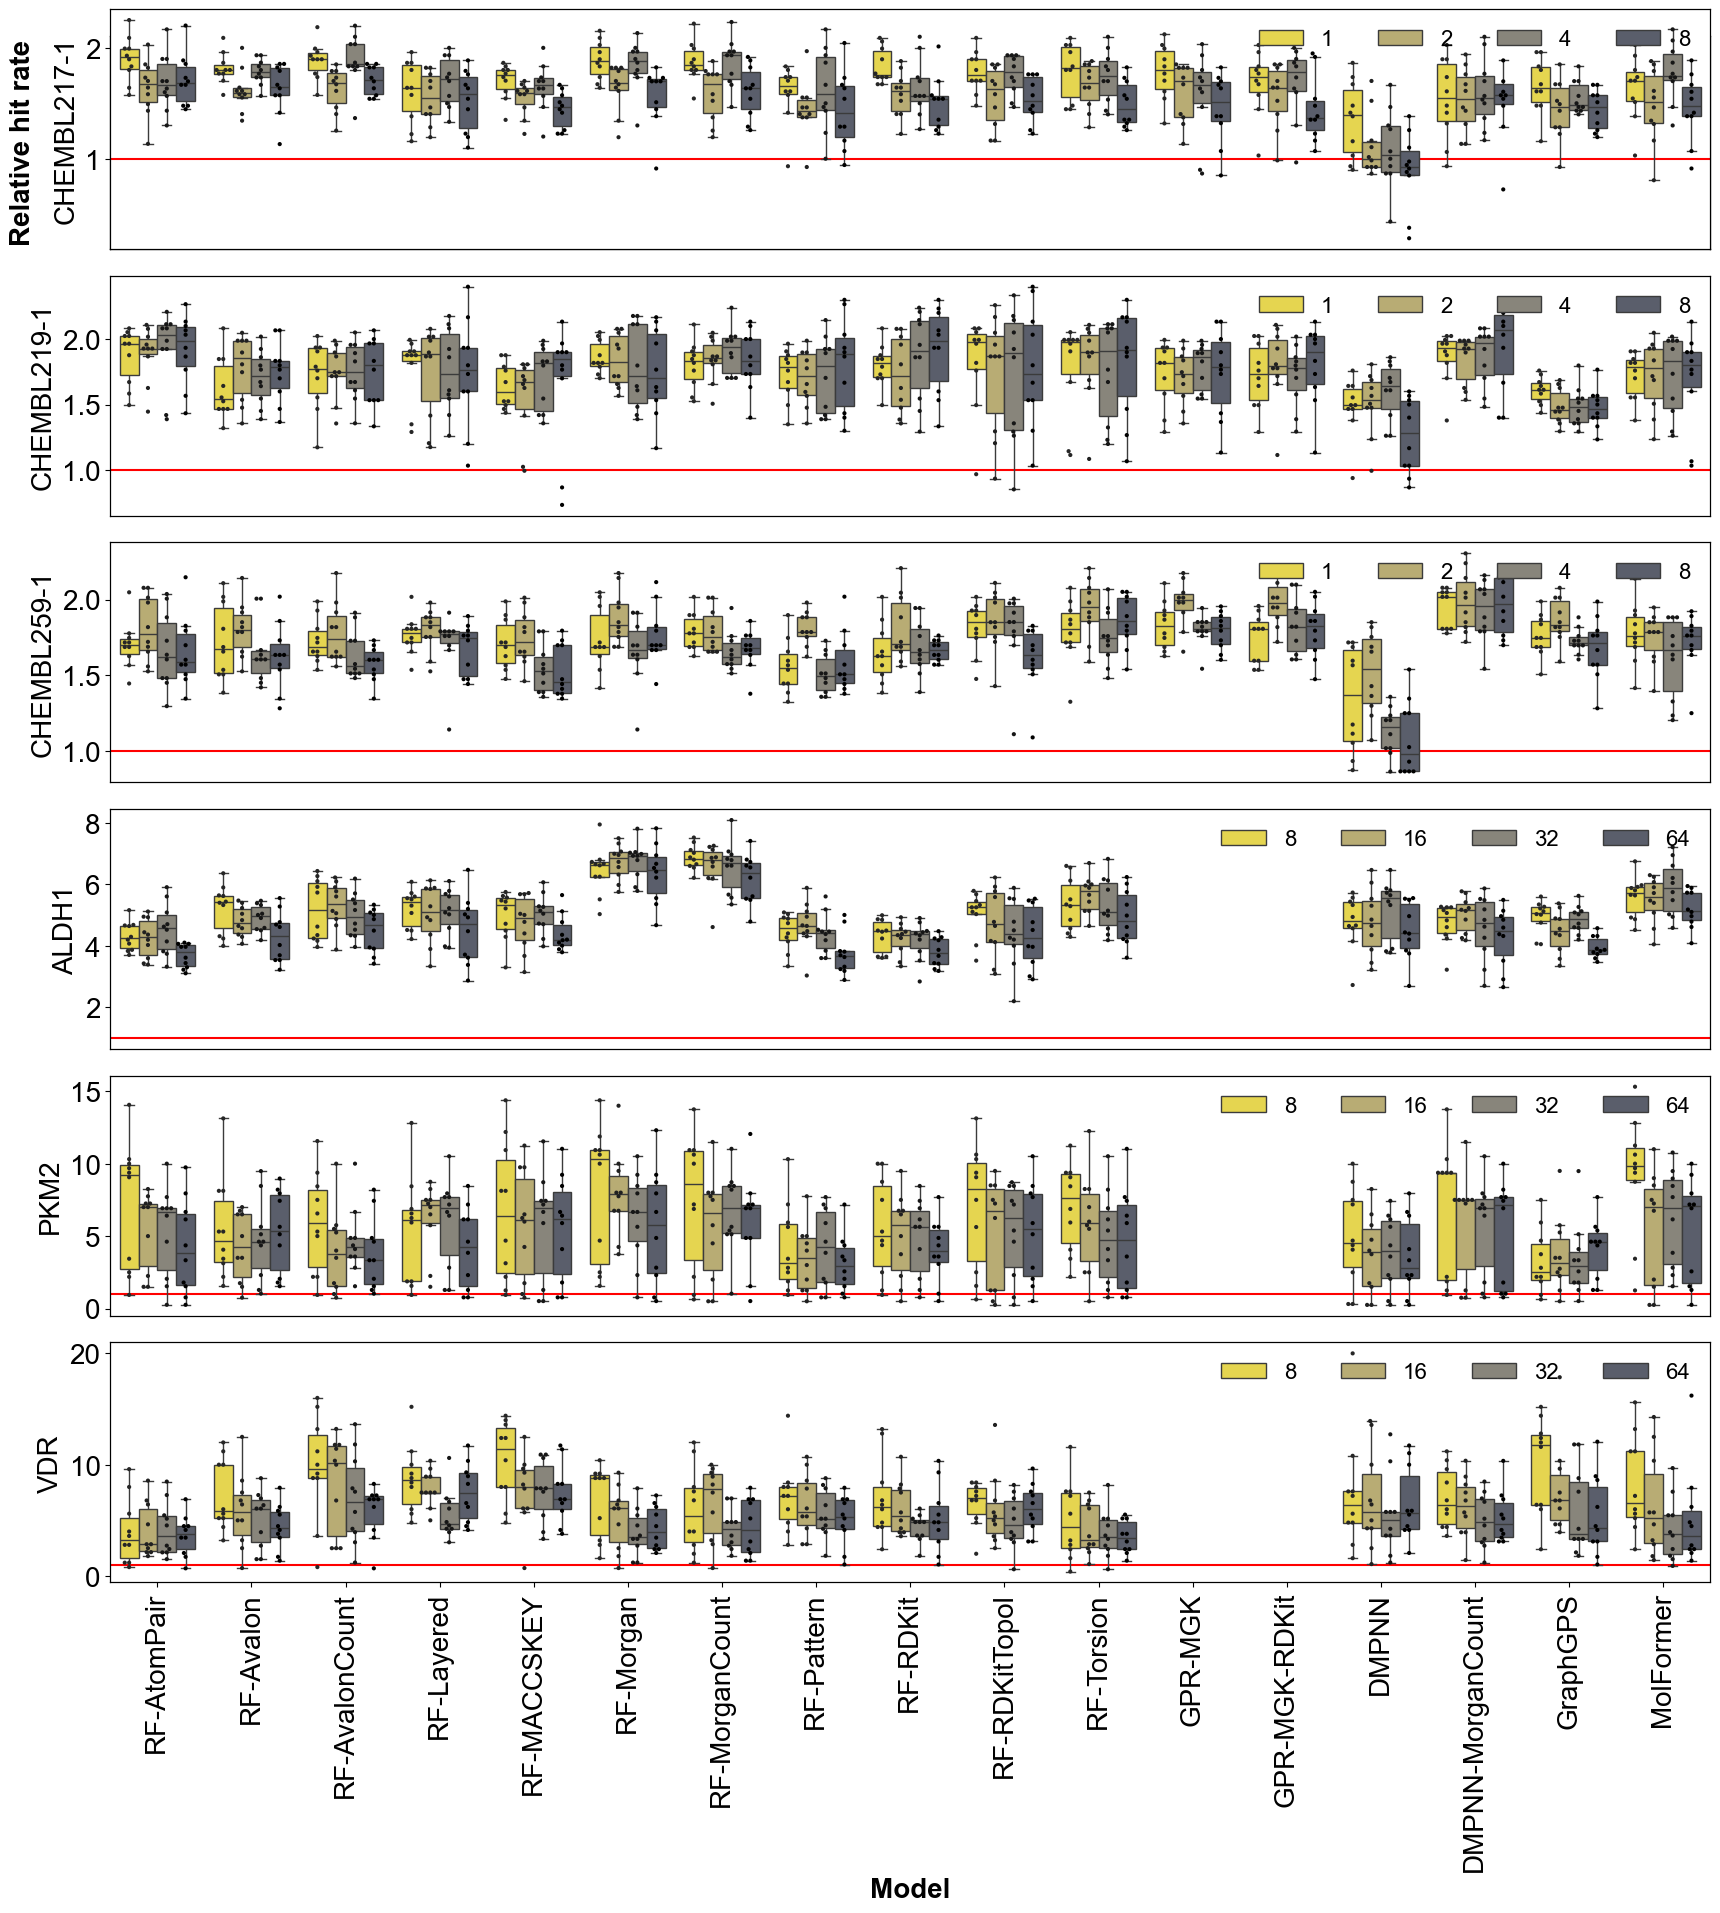

In [15]:
fs = 8
params = {'legend.fontsize': '%s' % (2 * fs),
          'figure.figsize': (fs * 2, fs * 2),  # 8*6
          'axes.labelsize': '%s' % (2.5 * fs),
          'axes.titlesize': '%s' % (2.5 * fs),
          'xtick.labelsize': '%s' % (2.5 * fs),
          'ytick.labelsize': '%s' % (2.5 * fs),
          'font.family': 'Arial',
          'axes.linewidth': fs / 9,
          'image.cmap': 'viridis'
          }
pylab.rcParams.update(params)
fig = plt.figure()
fig.tight_layout()
plt.rcParams.update(params)

dx = 1 / 6
ax = fig.add_axes([0, 1, 1, dx* 0.8])
ax.set_ylabel('Relative hit rate', labelpad=50, fontweight='bold')
ax.set_xticks([])
ax.set_yticks([])

for i in range(6):
    ax = fig.add_axes([0, 1 - dx * i, 1, dx* 0.9])
    ax.axhline(1, color='red')
    orders = models1
    df = df1[df1.dataset == datasets1[i]]
    sns.swarmplot(data=df, x="model", y="performance", hue="batch_size", ax=ax, 
                  dodge=True, alpha=1.0, size=3, palette='dark:black', 
                  legend=False, order=orders)
    sns.boxplot(df, x="model", y="performance", hue="batch_size", ax=ax, palette=cividis10[:2:-2], legend=True, order=orders, showfliers=False)
    legend = ax.legend(loc='upper right', ncol=4, frameon=False)
    # plt.setp(ax.get_xticklabels(), rotation=90, ha='center')
    if i != 5:
        ax.set_xticks([])
        ax.set_xlabel("")
    else:
        ax.set_xlabel('Model', fontweight='bold')
        ax.set_xticks(range(17))
        ax.set_xticklabels(models1, rotation=90)
    # ax.set_title(datasets1[i])
    ax.set_ylabel(datasets1[i])
    ax.set_xlim([-0.5, 16.5])
plt.savefig('Sfigure2.svg', format='svg', dpi=1200, bbox_inches='tight')